# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Load Data

In [2]:
df = pd.read_csv('Dataset A/1A.tsv', delimiter='\t')
df.head()

,ID,Registration Date,Drug,Birth Date,Gender,Ascites,Hepatomegaly,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alkaline Phospatase (U/L),SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,2023/11/07,D-penicillamine,1966/03/07,F,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,Stage4
1,2,2012/08/16,D-penicillamine,1968/07/01,F,N,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,stage_3
2,3,2022/03/05,D-penicillamine,1954/11/15,M,N,N,S,1.4,NaN,3.48,210.0,516.0,96.10,55.0,151.0,12.0,Stage4
3,4,2019/09/04,D-penicillamine,1970/03/16,F,N,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,Stage4
4,5,2020/10/29,Placebo,1986/11/03,F,N,Y,N,3.4,NaN,3.53,143.0,671.0,113.15,72.0,136.0,10.9,stage_3


In [3]:
df.shape

(418, 18)

# Pre EDA Processing

## Removing Useless Columns

- ID : It is just a unique identifier for each row.
- Registration Date : It is just the date when the user registered.

In [4]:
df = df.drop(['ID', 'Registration Date'], axis=1)

## Tranform Birth Date to Day, Month, Year

In [5]:
# Transform Birth Date to day, month and year
df['Birth Date'] = pd.to_datetime(df['Birth Date'])
df['Birth Year'] = df['Birth Date'].dt.year
df['Birth Month'] = df['Birth Date'].dt.month
df['Birth Day'] = df['Birth Date'].dt.day

df = df.drop(['Birth Date'], axis=1)

In [6]:
df.head()

,Drug,Gender,Ascites,Hepatomegaly,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alkaline Phospatase (U/L),SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Birth Year,Birth Month,Birth Day
0,D-penicillamine,F,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,Stage4,1966,3,7
1,D-penicillamine,F,N,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,stage_3,1968,7,1
2,D-penicillamine,M,N,N,S,1.4,NaN,3.48,210.0,516.0,96.10,55.0,151.0,12.0,Stage4,1954,11,15
3,D-penicillamine,F,N,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,Stage4,1970,3,16
4,Placebo,F,N,Y,N,3.4,NaN,3.53,143.0,671.0,113.15,72.0,136.0,10.9,stage_3,1986,11,3


# EDA

## Check for Missing Values

In [7]:
# Check for missing values
df.isnull().sum()

Drug                         106
Gender                         0
Ascites                      106
Hepatomegaly                 106
Edema                          0
Bilirubin                      0
Cholesterol                  338
Albumin                        0
Copper                       108
Alkaline Phospatase (U/L)    106
SGOT                         106
Tryglicerides                  0
Platelets                     11
Prothrombin                    2
Stage                          6
Birth Year                     0
Birth Month                    0
Birth Day                      0
dtype: int64

## Check for Duplicates

In [8]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

## Check Column Data Types

In [9]:
# Check column types

df.dtypes

Drug                          object
Gender                        object
Ascites                       object
Hepatomegaly                  object
Edema                         object
Bilirubin                    float64
Cholesterol                  float64
Albumin                      float64
Copper                       float64
Alkaline Phospatase (U/L)    float64
SGOT                         float64
Tryglicerides                float64
Platelets                    float64
Prothrombin                  float64
Stage                         object
Birth Year                     int32
Birth Month                    int32
Birth Day                      int32
dtype: object

## Check Unique Values

In [10]:
# Check Unique values
df.nunique()

Drug                           5
Gender                         2
Ascites                        2
Hepatomegaly                   2
Edema                          3
Bilirubin                     98
Cholesterol                   69
Albumin                      154
Copper                       158
Alkaline Phospatase (U/L)    295
SGOT                         179
Tryglicerides                147
Platelets                    243
Prothrombin                   48
Stage                          4
Birth Year                    50
Birth Month                   12
Birth Day                     31
dtype: int64

## Check Data Distribution

In [11]:
Numerical_columns = []
Categorical_columns = []

for i in df.columns:
    if df[i].dtype == 'object':
        Categorical_columns.append(i)
    else:
        Numerical_columns.append(i)

### Numerical Features

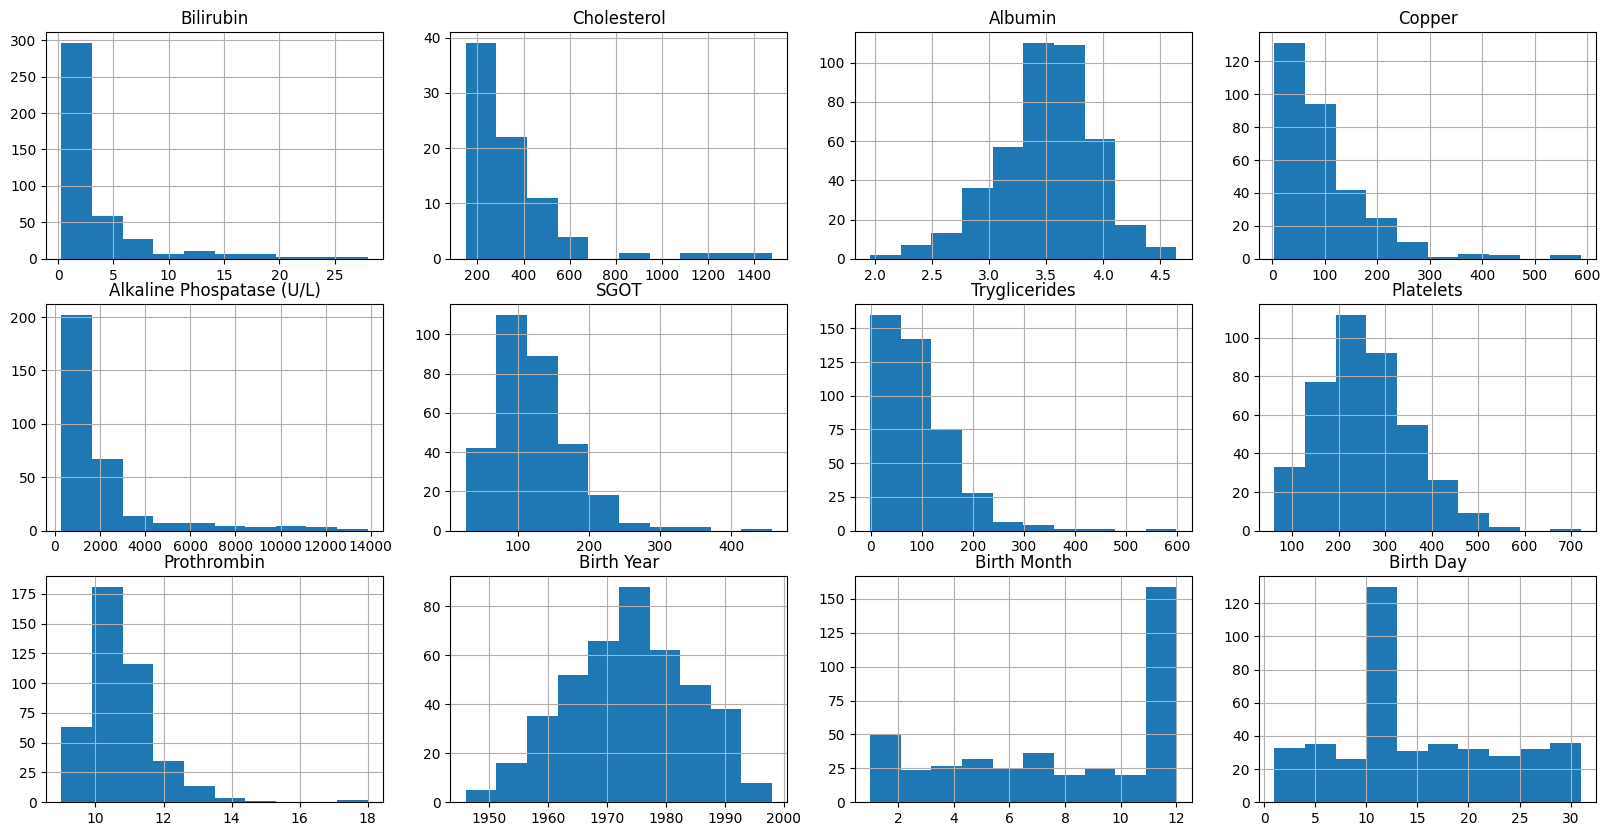

In [12]:
# Plot the distribution of numerical columns into 1 plot
plt.figure(figsize=(20, 10))
for i, col in enumerate(Numerical_columns, 1):
    plt.subplot(3, 4, i)
    df[col].hist()
    plt.title(col)

From the distribution plot, we can see that the some of the numerical features are not normally distributed. We can see that the bilirubin, cholesteros, copper, Alkaline Phospate, SGOT, Tryglicerides, and Prothombin are right-skewed, Birth Month being left skewed, and with the rest being somewhat normal.

### Categorical Features

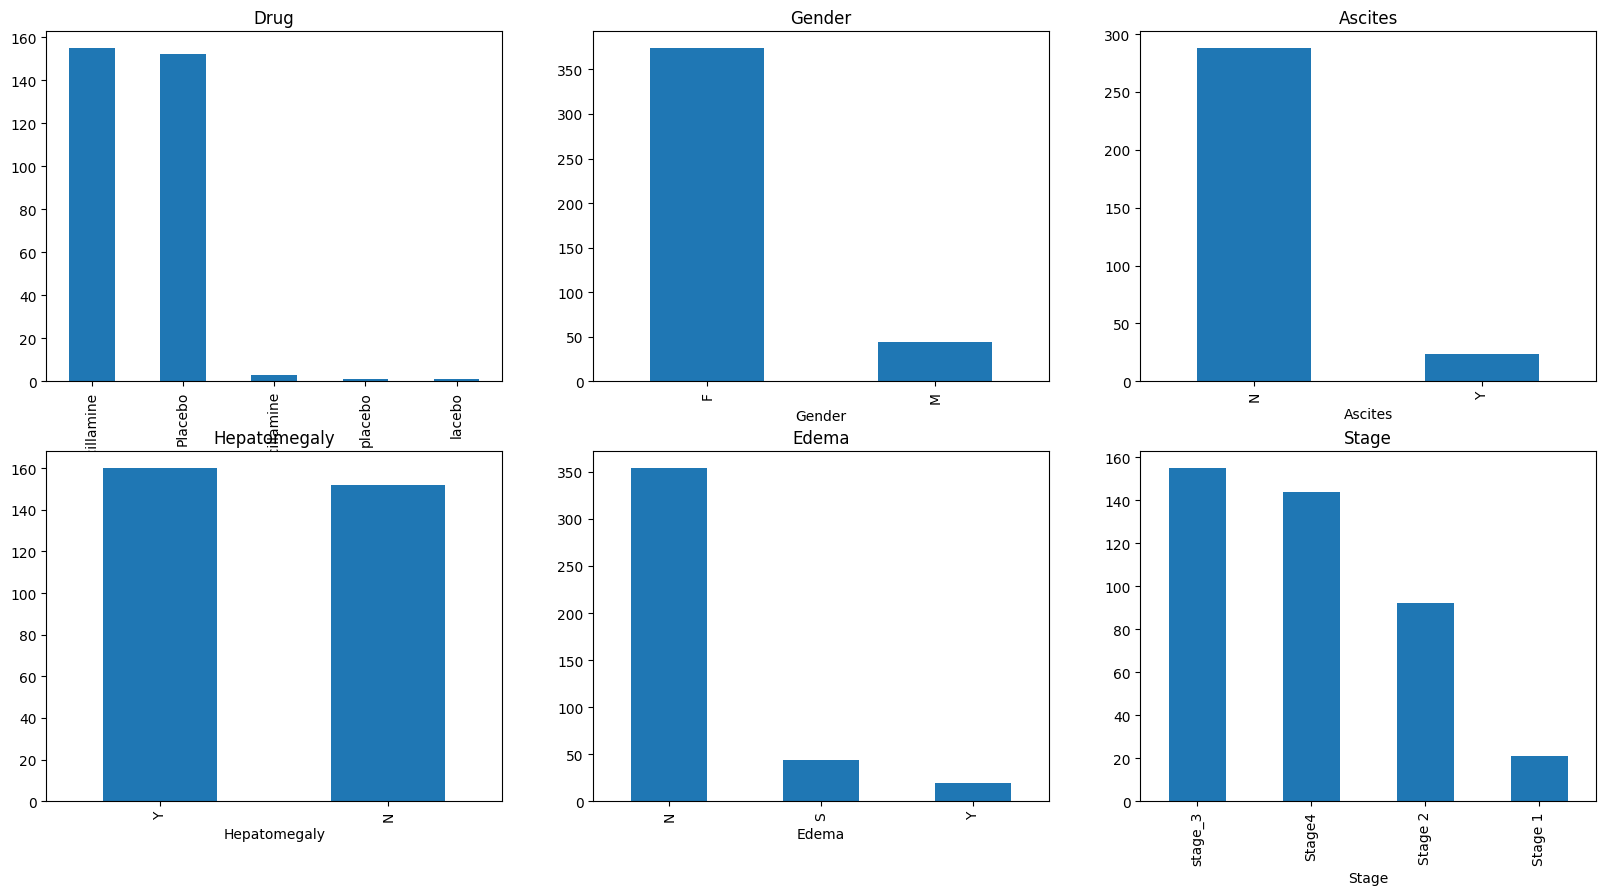

In [13]:
# Plot the distribution of categorical columns into 1 plot
plt.figure(figsize=(20, 10))
for i, col in enumerate(Categorical_columns, 1):
    plt.subplot(2, 3, i)
    df[col].value_counts().plot.bar()
    plt.title(col)

Fromt he plot, we can see that some features are imbalanced : 
- Edema (S & Y are underrepresented)
- Ascites (Y is underrepresented)
- Gender (F is underrepresented)
- Stage (Stage 1 is underrepresented)

We can also see that in the drug there's some typo in the drug name, we can fix this later.

# Preprocess

## Handling Data
- Fix Typo in Drug Name
- Handle Missing Values
- SMOTE for Imbalanced Data

### Fix Typo in Drug Name

In [14]:
# Fix Drug names typo

# Right name D-penicillamine and Placebo

unique_drugs = df['Drug'].unique()

# Replace the wrong names
df['Drug'] = df['Drug'].replace('d-penicillamine', 'D-Penicillamine')
df['Drug'] = df['Drug'].replace('D-penicillamine', 'D-Penicillamine')
df['Drug'] = df['Drug'].replace('placebo', 'Placebo')
df['Drug'] = df['Drug'].replace('lacebo', 'Placebo')

In [15]:
unique_drugs

array(['D-penicillamine', 'Placebo', 'placebo', 'lacebo',
       'd-penicillamine', nan], dtype=object)

### Handle Missing Values

- Catetorical Features : Fill with Mode
- Numerical Features : Fill with Median

In [16]:
# Categical columns Missing values to mode
for i in Categorical_columns:
    df[i] = df[i].fillna(df[i].mode()[0])
    
# Numerical columns Missing values to median
for i in Numerical_columns:
    df[i] = df[i].fillna(df[i].median())

## For Model Training
- Split Data into Train and Test
- Scale Data
- Feature Encoding
- Feature Selection with Feature Importance

### Split Data into Train and Test

In [17]:
target = df['Stage']
df = df.drop('Stage', axis=1)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df, target, test_size=0.2, random_state=42)

### Scale Data

In [18]:
# Scale Numerical columns
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[Numerical_columns] = scaler.fit_transform(X_train[Numerical_columns])
X_test[Numerical_columns] = scaler.transform(X_test[Numerical_columns])

### SMOTE for Imbalanced Data

In [19]:
# Smote for imbalanced data
from imblearn.over_sampling import SMOTENC

Categorical_columns.remove('Stage')

smote = SMOTENC(categorical_features=[X_train.columns.get_loc(i) for i in Categorical_columns], random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

### Feature Encoding

In [20]:
# Feature Encoding

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown='infrequent_if_exist')

X_train_encoded = pd.DataFrame(encoder.fit_transform(X_train[Categorical_columns]).toarray(), columns=encoder.get_feature_names_out(Categorical_columns))
X_test_encoded = pd.DataFrame(encoder.transform(X_test[Categorical_columns]).toarray(), columns=encoder.get_feature_names_out(Categorical_columns))

X_train_encoded.index = X_train.index
X_test_encoded.index = X_test.index


In [21]:
X_train = pd.concat([X_train, X_train_encoded], axis=1)
X_test = pd.concat([X_test, X_test_encoded], axis=1)

X_train = X_train.drop(Categorical_columns, axis=1)
X_test = X_test.drop(Categorical_columns, axis=1)

In [22]:
X_train.head()

,Bilirubin,Cholesterol,Albumin,Copper,Alkaline Phospatase (U/L),SGOT,Tryglicerides,Platelets,Prothrombin,Birth Year,...,Drug_Placebo,Gender_F,Gender_M,Ascites_N,Ascites_Y,Hepatomegaly_N,Hepatomegaly_Y,Edema_N,Edema_S,Edema_Y
0,-0.293650,-0.131384,0.332534,-0.223549,-0.271978,-0.041459,-1.091195,-1.227585,-0.726142,-0.522029,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
1,-0.293650,-0.401558,-0.380039,0.189946,3.213896,-0.755112,0.896627,0.272174,-0.101865,-0.333432,...,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
2,-0.223106,-0.401558,-0.047505,-0.445064,0.183305,-0.592131,-0.028523,-0.358759,0.834549,0.326656,...,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
3,1.328852,-0.131384,0.926345,0.278552,-0.632267,0.009612,1.946797,0.396292,-1.142326,0.232358,...,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,-0.552310,-0.131384,0.427544,-0.223549,-0.271978,-0.041459,-1.091195,0.479037,-1.246372,0.703850,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0


# Model Fine Tuning

## Random Forest (Fine Tuning)

In [23]:
# Finetuning Random Forest (3 hyperparameters)
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=0)

grid_search.fit(X_train, y_train)

grid_search.best_params_

{'max_depth': 30, 'min_samples_split': 2, 'n_estimators': 300}

## XGBoost (Fine Tuning)

In [24]:
import optuna
from xgboost import XGBClassifier

# Ensure y_train_xg and y_test_xg are integers
y_train_xg = y_train.replace({'Stage 1': 0, 'Stage 2': 1, 'stage_3': 2, 'Stage4': 3}).astype(int)
y_test_xg = y_test.replace({'Stage 1': 0, 'Stage 2': 1, 'stage_3': 2, 'Stage4': 3}).astype(int)

def objective(trial):
    # Define hyperparameters to tune
    params = {
        'max_depth': trial.suggest_int('max_depth', 2, 10, 15),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 1.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
    }

    # Train XGBoost model with the selected hyperparameters
    model = XGBClassifier(**params)
    model.fit(X_train, y_train_xg)

    # Evaluate model on validation set
    val_score = model.score(X_test, y_test_xg)
    return val_score

# Create Optuna study
study = optuna.create_study(direction='maximize')

# Optimize hyperparameters
study.optimize(objective, n_trials=100)

# Train final model with best hyperparameters
best_params = study.best_params

# Clear output
from IPython.display import clear_output
clear_output()

print(f"Best parameters: {best_params}")


Best parameters: {'max_depth': 2, 'learning_rate': 0.3204191676618394, 'subsample': 0.5000350869793483, 'colsample_bytree': 0.7541967361820267}


# Train Model

## Random Forest

In [25]:
rf = RandomForestClassifier(**grid_search.best_params_)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     Stage 1       0.17      0.33      0.22         3
     Stage 2       0.24      0.31      0.27        16
      Stage4       0.68      0.68      0.68        31
     stage_3       0.54      0.41      0.47        34

    accuracy                           0.49        84
   macro avg       0.41      0.43      0.41        84
weighted avg       0.52      0.49      0.50        84



## XGBoost

In [26]:
xgb = XGBClassifier(**best_params)
xgb.fit(X_train, y_train_xg)

y_pred_xgb = xgb.predict(X_test)

print(classification_report(y_test_xg, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.20      0.67      0.31         3
           1       0.33      0.31      0.32        16
           2       0.67      0.53      0.59        34
           3       0.72      0.74      0.73        31

    accuracy                           0.57        84
   macro avg       0.48      0.56      0.49        84
weighted avg       0.61      0.57      0.58        84



## Train Conclusion

### Analysis of Training Results

#### **1. Random Forest**
- **Accuracy**: 49%
- **Precision, Recall, and F1-Score**:
  - **Stage 1**: 
    - Precision (0.17) and recall (0.33) are very low, indicating poor performance in predicting this stage.
    - F1-Score (0.22) suggests weak balance between precision and recall.
  - **Stage 2**: 
    - Precision (0.24) and recall (0.31) are low, with a marginally better F1-score of 0.27.
  - **Stage 4**: 
    - Strong performance with balanced precision, recall, and F1-score of 0.68.
  - **Stage 3**: 
    - Precision (0.54) and recall (0.41) indicate moderate performance, with F1-score at 0.47.
- **Macro Average**: 
  - Precision (0.41), recall (0.43), and F1-score (0.41) show an overall struggle to generalize across all classes.
- **Weighted Average**: 
  - Better than macro average, with F1-score at 0.50, due to the higher support for Stage 4 and Stage 3.

#### **2. XGBoost**
- **Accuracy**: 57%
- **Precision, Recall, and F1-Score**:
  - **Stage 0**: 
    - Precision (0.20) is very low, but recall (0.67) is high, suggesting the model predicts many false positives while capturing true positives.
    - F1-score (0.31) reflects this imbalance.
  - **Stage 1**: 
    - Precision (0.33) and recall (0.31) are slightly better than Random Forest, with F1-score at 0.32.
  - **Stage 2**: 
    - Precision (0.67) and recall (0.53) show better performance, F1-score at 0.59.
  - **Stage 3**: 
    - Strong performance with precision (0.72), recall (0.74), and F1-score at 0.73.
- **Macro Average**:
  - Precision (0.48), recall (0.56), and F1-score (0.49) indicate moderate balance across all classes.
- **Weighted Average**:
  - Stronger metrics overall, with F1-score at 0.58, due to higher support for Stage 2 and Stage 3.

---

### **Key Insights**
1. **Accuracy Comparison**: XGBoost (57%) outperforms Random Forest (49%) in overall accuracy.
2. **Class-Level Performance**:
   - Both models struggle with minority classes (Stages 1 and 0).
   - XGBoost shows better recall for minority classes but at the cost of precision, especially for Stage 0.
   - Both models perform well on majority classes (Stage 4 and Stage 3), with XGBoost having a slight edge.
3. **F1-Score**:
   - XGBoost has higher F1-scores across most stages, indicating better balance between precision and recall.
4. **Macro vs. Weighted Averages**:
   - Macro averages for both models are low due to poor performance on minority classes.
   - Weighted averages reflect better performance because majority classes dominate.

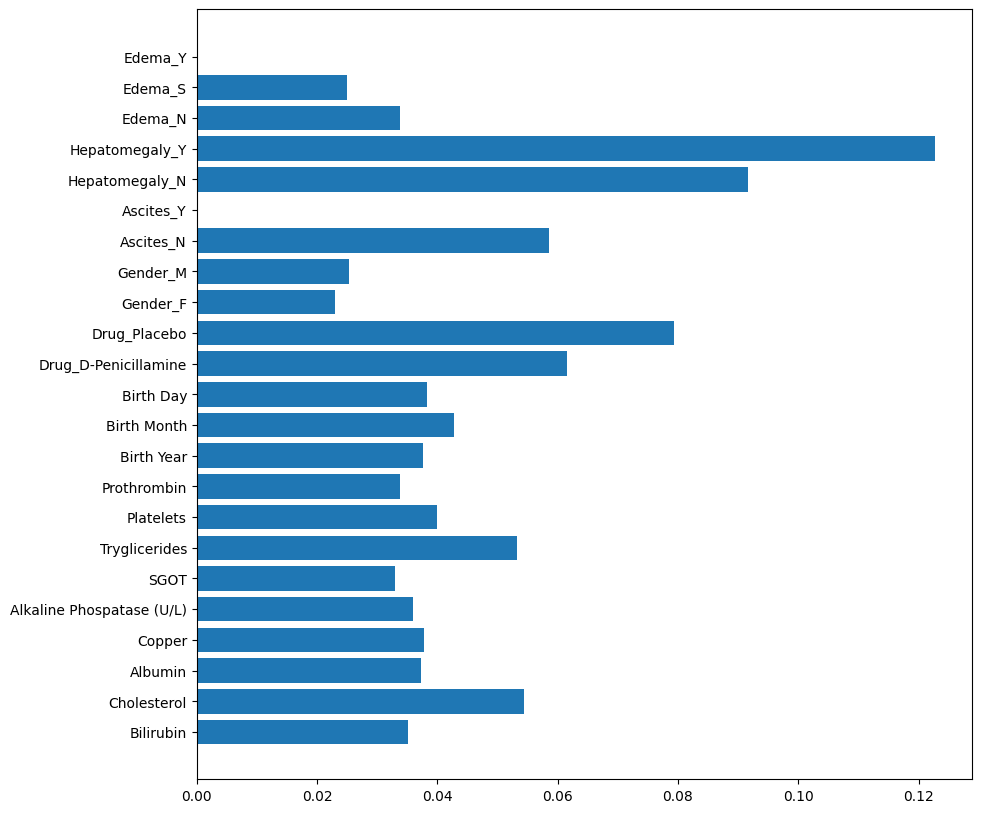

In [28]:
# Feature Importance from XGBoost
plt.figure(figsize=(10, 10))
plt.barh(X_train.columns, xgb.feature_importances_)
plt.show()

### Top 10 Features (Ranked by Importance from Chart):
1. **Hepatomegaly_Y**  
   High importance suggests that the presence of hepatomegaly (enlarged liver) significantly influences the model's predictions.
   
2. **Drug_Placebo**  
   Indicates whether the individual received a placebo drug, implying it strongly impacts the outcome under study.

3. **Drug_D-Penicillamine**  
   The use of this specific drug is highly impactful, showing its relevance to the model's target variable.

4. **Hepatomegaly_N**  
   The absence of hepatomegaly is also critical, complementing the significance of its presence.

5. **Cholesterol**  
   The cholesterol level of an individual plays a substantial role in influencing the model's predictions.

6. **Gender_F**  
   Gender, specifically female, has an evident importance in the dataset.

7. **Copper**  
   Copper levels are influential, likely related to the condition or outcome being modeled.

8. **Albumin**  
   This protein's levels indicate its relevance to the underlying condition or outcome.

9. **Alkaline Phosphatase (U/L)**  
   A liver enzyme with considerable importance, showing its diagnostic or predictive value.

10. **Edema_N**  
    The absence of edema (swelling) holds relevance, hinting at its diagnostic implications.

---

### Analysis:
- **Hepatomegaly (presence/absence):** The feature split for both presence (`Hepatomegaly_Y`) and absence (`Hepatomegaly_N`) is critical. This indicates the condition's significant impact on the target variable, such as disease progression or treatment outcome.
  
- **Drug-related features:** The model places high importance on drug variables (`Drug_Placebo` and `Drug_D-Penicillamine`), reflecting the impact of medication or its absence on the predictions.
  
- **Biochemical markers:** Features like cholesterol, copper, albumin, and alkaline phosphatase highlight the importance of biological measurements in predicting the outcome. They likely serve as indicators of liver or systemic health.
  
- **Gender-specific factors:** Gender plays a role, potentially due to biological differences or varying responses to treatment/conditions between males and females.
  
- **Edema:** The absence of edema (`Edema_N`) being important suggests its role as a predictive marker, either for diagnosis or response to treatment.

This analysis shows the blend of clinical, biochemical, and demographic variables contributing to the model's understanding of the target condition. If you have the data or model context, I can provide more specific insights!